In [53]:
import pandas as pd
import matplotlib.pyplot as plt

In [54]:
df = pd.read_csv('MBTA_2023_System-Wide_Passenger_Survey_Data.csv')

demog_groups = [
    "Race and Ethnicity",
    "Income",
    "Other Demographics",  # contains age breakdowns (e.g. 18–29, 30–44, etc.)
    "Trip Purpose and Frequency",  # optional
    # add any others you want to inspect...
]
df_demo = df[df["measure_group"].isin(demog_groups)].copy()

In [55]:
modes = ["Bus", "Subway", "Commuter Rail", "Ferry", "Select Bus Service"]
df_demo = df_demo[df_demo["service_mode"].isin(modes)]

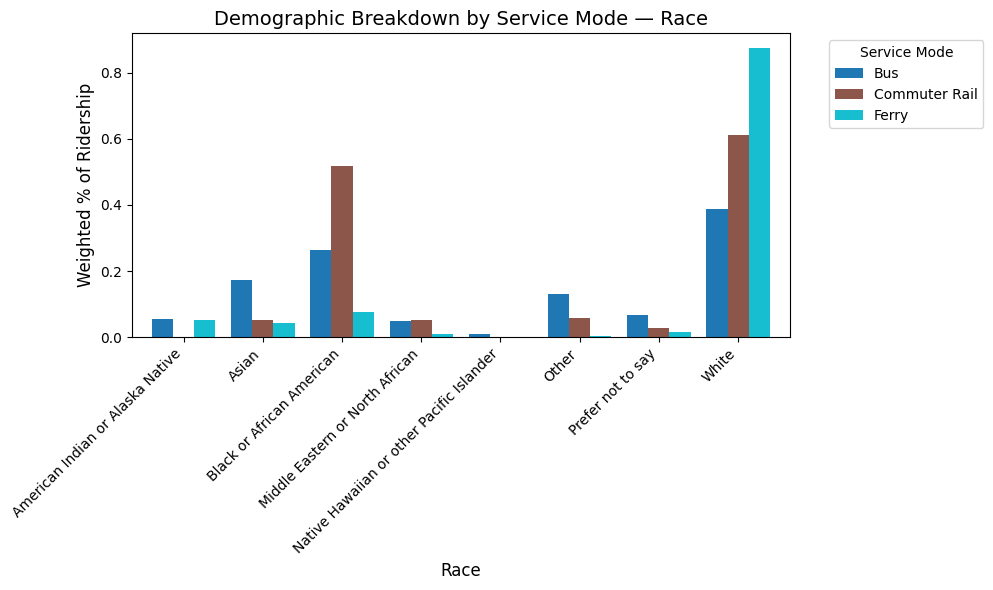

In [56]:
sub = df_demo[df_demo["measure"] == "Race"].copy()

sub["weighted_percent"] = pd.to_numeric(sub["weighted_percent"], errors="coerce")

# 3) Drop any rows that failed to convert (just in case)
sub = sub.dropna(subset=["weighted_percent"])

# 4) Pivot so rows=Race category, cols=service_mode, values=weighted_percent
pivot = (
    sub.pivot_table(
        index="category",
        columns="service_mode",
        values="weighted_percent",
        aggfunc="first",
    )
    .sort_index()
    # and ensure every column is float
    .astype(float)
)

# 5) Plot with pure matplotlib
fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(
    kind="bar",
    width=0.8,
    colormap="tab10",
    ax=ax,
)
ax.set_title("Demographic Breakdown by Service Mode — Race", fontsize=14)
ax.set_ylabel("Weighted % of Ridership", fontsize=12)
ax.set_xlabel("Race", fontsize=12)
ax.legend(title="Service Mode", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

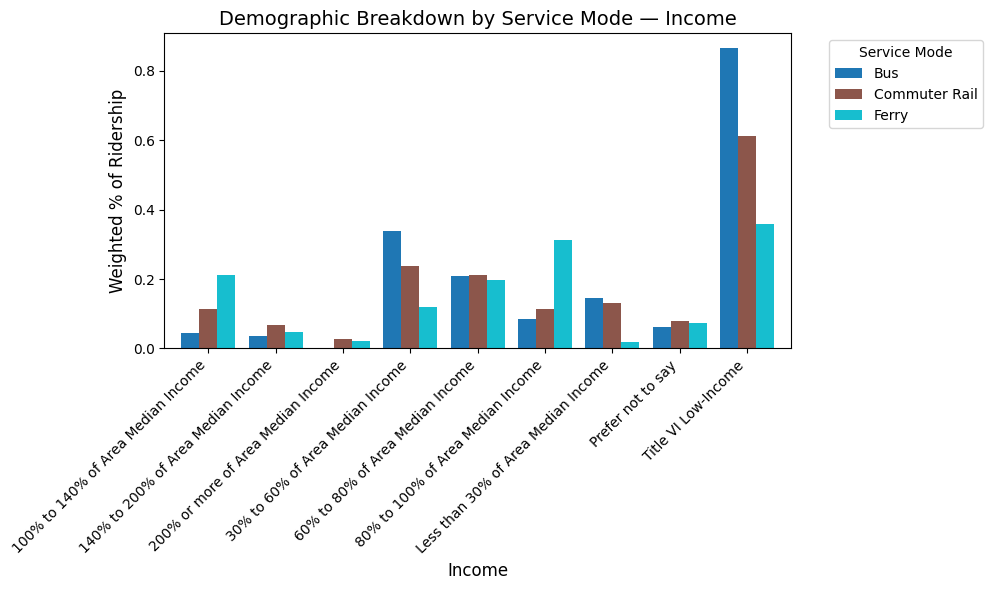

In [57]:
sub = df_demo[df_demo["measure"].isin(["Title VI Low-Income"])].copy()

# now fix the category column in-place
to_fix = ["Title VI Low-Income"]
mask = df_demo["measure"].isin(to_fix)

# 1) Where category == "Yes", replace with the measure name
df_demo.loc[mask & (df_demo["category"] == "Yes"), "category"] = (
    df_demo.loc[mask & (df_demo["category"] == "Yes"), "measure"]
)

sub = df_demo[df_demo["measure"].isin([
    "Household Income",
    "Title VI Low-Income"
])].copy()

sub = sub[sub["category"] != "No"]


sub["weighted_percent"] = pd.to_numeric(sub["weighted_percent"], errors="coerce")

# 3) Drop any rows that failed to convert (just in case)
sub = sub.dropna(subset=["weighted_percent"])

# 4) Pivot so rows=Race category, cols=service_mode, values=weighted_percent
pivot = (
    sub.pivot_table(
        index="category",
        columns="service_mode",
        values="weighted_percent",
        aggfunc="first",
    )
    .sort_index()
    # and ensure every column is float
    .astype(float)
)

# 5) Plot with pure matplotlib
fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(
    kind="bar",
    width=0.8,
    colormap="tab10",
    ax=ax,
)
ax.set_title("Demographic Breakdown by Service Mode — Income", fontsize=14)
ax.set_ylabel("Weighted % of Ridership", fontsize=12)
ax.set_xlabel("Income", fontsize=12)
ax.legend(title="Service Mode", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/var/folders/53/8ymq9sy57ds0rpj5jm0__l_w0000gn/T/ipykernel_6528/1071663887.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub["weighted_percent"] = pd.to_numeric(sub["weighted_percent"], errors="coerce")


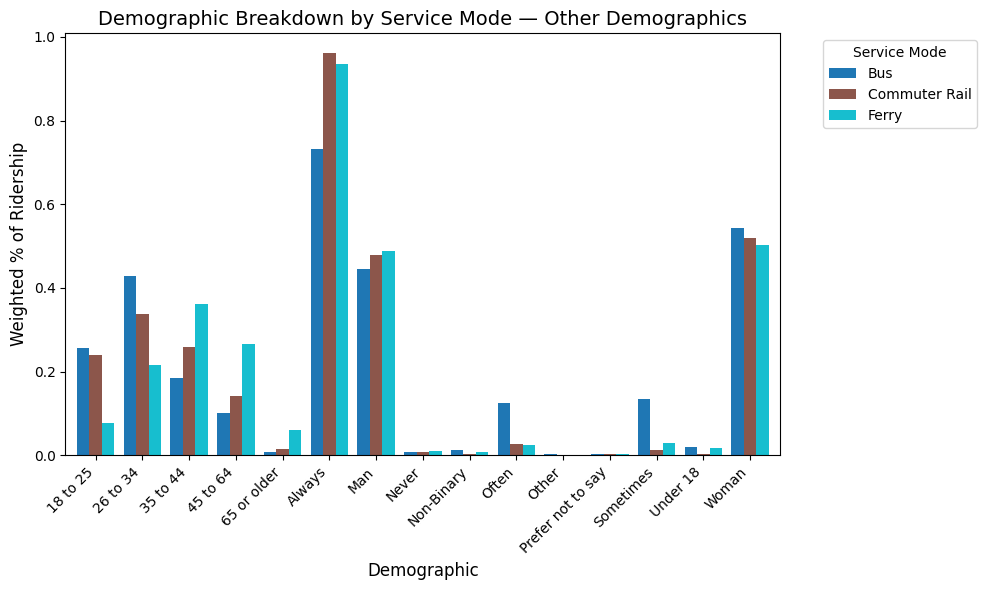

In [58]:
sub = df_demo[df_demo["measure_group"] == "Other Demographics"]

sub["weighted_percent"] = pd.to_numeric(sub["weighted_percent"], errors="coerce")

# 3) Drop any rows that failed to convert (just in case)
sub = sub.dropna(subset=["weighted_percent"])

# 4) Pivot so rows=Race category, cols=service_mode, values=weighted_percent
pivot = (
    sub.pivot_table(
        index="category",
        columns="service_mode",
        values="weighted_percent",
        aggfunc="first",
    )
    .sort_index()
    # and ensure every column is float
    .astype(float)
)

# 5) Plot with pure matplotlib
fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(
    kind="bar",
    width=0.8,
    colormap="tab10",
    ax=ax,
)
ax.set_title("Demographic Breakdown by Service Mode — Other Demographics", fontsize=14)
ax.set_ylabel("Weighted % of Ridership", fontsize=12)
ax.set_xlabel("Demographic", fontsize=12)
ax.legend(title="Service Mode", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/var/folders/53/8ymq9sy57ds0rpj5jm0__l_w0000gn/T/ipykernel_6528/858319308.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub["weighted_percent"] = pd.to_numeric(sub["weighted_percent"], errors="coerce")


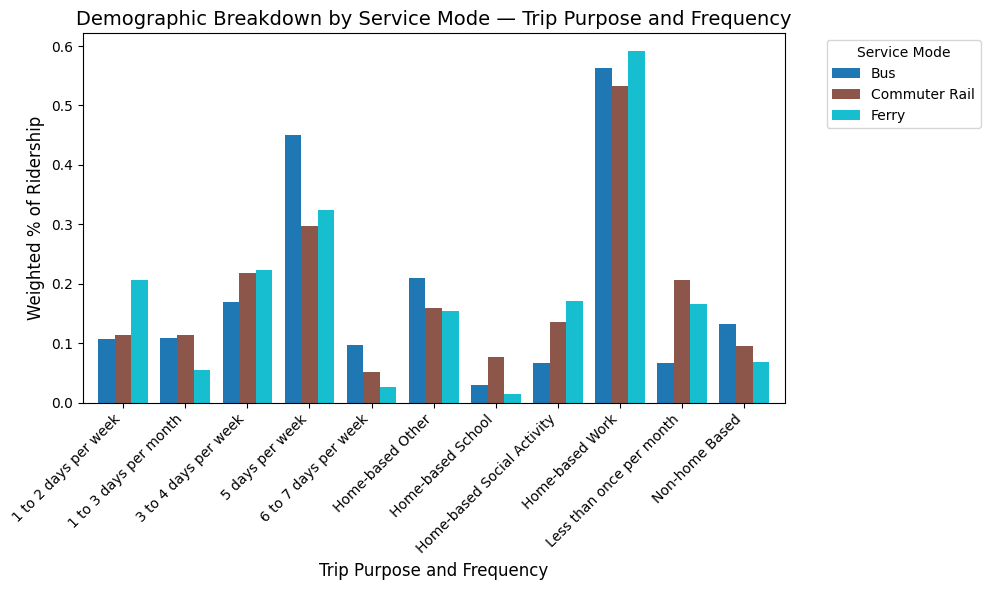

In [59]:
sub = df_demo[df_demo["measure_group"] == "Trip Purpose and Frequency"]

sub["weighted_percent"] = pd.to_numeric(sub["weighted_percent"], errors="coerce")

# 3) Drop any rows that failed to convert (just in case)
sub = sub.dropna(subset=["weighted_percent"])

# 4) Pivot so rows=Race category, cols=service_mode, values=weighted_percent
pivot = (
    sub.pivot_table(
        index="category",
        columns="service_mode",
        values="weighted_percent",
        aggfunc="first",
    )
    .sort_index()
    # and ensure every column is float
    .astype(float)
)

# 5) Plot with pure matplotlib
fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(
    kind="bar",
    width=0.8,
    colormap="tab10",
    ax=ax,
)
ax.set_title("Demographic Breakdown by Service Mode — Trip Purpose and Frequency", fontsize=14)
ax.set_ylabel("Weighted % of Ridership", fontsize=12)
ax.set_xlabel("Trip Purpose and Frequency", fontsize=12)
ax.legend(title="Service Mode", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()